# This project is about predicting the car price based on the input features by Multiple Linear Regression.

## Problem Statement
A Chinese automobile company Geely Auto aspires to enter the US market by setting up their manufacturing unit there and producing cars locally to give competition to their US and European counterparts.

They have contracted an automobile consulting company to understand the factors on which the pricing of cars depends. Specifically, they want to understand the factors affecting the pricing of cars in the American market, since those may be very different from the Chinese market. The company wants to know:

Which variables are significant in predicting the price of a car
How well those variables describe the price of a car
Based on various market surveys, the consulting firm has gathered a large data set of different types of cars across the America market

## Business Goal
We are required to model the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

In [1647]:
import pandas as pd
import numpy as np


In [1648]:
# loading the dataset 
data = pd.read_csv('CarPrice_Assignment.csv')
data

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [1649]:
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [1650]:
data.tail()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


In [1651]:
data.sample()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
145,146,0,subaru r2,gas,turbo,four,sedan,4wd,front,97.0,...,108,mpfi,3.62,2.64,7.7,111,4800,24,29,11259.0


In [1652]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

# 1. Data Understanding / EDA
### Basic structure
1. How many rows and columns does the dataset have, and what are the data types of each column?

In [1653]:
data.shape

(205, 26)

rows = 205, columns = 26

2. Are there any missing or null values in any column?

In [1654]:
data.isna().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

No missing values in any columns.

3. Are there any duplicate rows?

In [1655]:
data.duplicated().sum()

np.int64(0)

No any duplicates.

In [1656]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [1657]:
data_description = pd.read_excel('Car_Price_Data_Dictionary.xlsx')
data_description_clean = data_description.iloc[:, :3]
data_description_clean.columns = ['S.No', 'Column Name', 'Description']
print("Description about all the columns...\n")
print(df_clean.to_markdown(index=False))

Description about all the columns...

|   S.No | Column Name               | Description                                                                                                                          |
|-------:|:--------------------------|:-------------------------------------------------------------------------------------------------------------------------------------|
|      1 | Car_ID                    | Unique id of each observation (Interger)                                                                                             |
|      2 | Symboling                 | Its assigned insurance risk rating, A value of +3 indicates that the auto is risky, -3 that it is probably pretty safe.(Categorical) |
|      3 | carCompany                | Name of car company (Categorical)                                                                                                    |
|      4 | fueltype                  | Car fuel type i.e gas or diesel (Categorical)        

4. What does the statistical summary (mean, median, min, max, std) look like for numeric columns?

In [1658]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


#### Target variable (price)
5. What is the distribution of price? Is it normally distributed or skewed?

Text(0.5, 1.0, 'Price Distribution ')

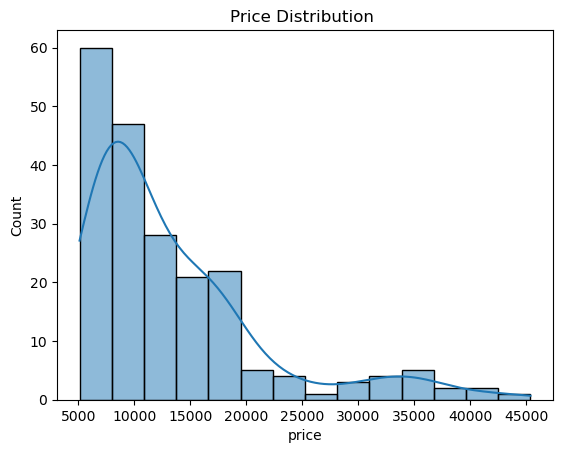

In [1659]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=data,
    x= data['price'],
    kde = True
)
plt.title("Price Distribution ")

the distribution of price is heavily right-skewed (positively skewed). It is not normally distributed.

6. What are the minimum, maximum, and average car prices?

In [1660]:
data['price'].describe()

count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

7. Are there any outliers in price?

In [1661]:
# Calculate Q1, Q3, and IQR
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter outliers on both ends
outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]

print(f"Lower Outlier Threshold: ${lower_bound:,.2f}")
print(f"Upper Outlier Threshold: ${upper_bound:,.2f}")
print(f"Total Outliers: {len(outliers)}")

Lower Outlier Threshold: $-5,284.50
Upper Outlier Threshold: $29,575.50
Total Outliers: 15


### Categorical variables
8. How many unique car companies are there? (Hint: CarName needs cleaning — it has company + model together, e.g. "alfa-romero giulia")

In [1662]:
data['CarName']

0            alfa-romero giulia
1           alfa-romero stelvio
2      alfa-romero Quadrifoglio
3                   audi 100 ls
4                    audi 100ls
                 ...           
200             volvo 145e (sw)
201                 volvo 144ea
202                 volvo 244dl
203                   volvo 246
204                 volvo 264gl
Name: CarName, Length: 205, dtype: object

In [1663]:
# 1. Extract the first word as company name (and convert to lowercase)
data['company'] = data['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Check uncleaned unique count
print("Uncleaned Unique Companies:", data['company'].nunique())

# 2. Fix typos and brand name inconsistencies
corrections = {
    'maxda': 'mazda',
    'porcshz': 'porsche',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'toyouta': 'toyota',
}

data['company'] = data['company'].replace(corrections)

# 3. Final Clean Count
print("Cleaned Unique Companies:", data['company'].nunique())
print("Unique Companies List:\n", sorted(data['company'].unique()))

Uncleaned Unique Companies: 27
Cleaned Unique Companies: 23
Unique Companies List:
 ['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porcshce', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


9. Which car company appears most frequently in the dataset?

In [1664]:
data['company'].value_counts()

company
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
porcshce        1
Name: count, dtype: int64

In [1665]:
data['company'].value_counts().idxmax()

'toyota'

Car company 'toyota' appears most frequently in the dataset.

10. What is the distribution of fueltype (gas vs diesel)? Does fuel type affect price?

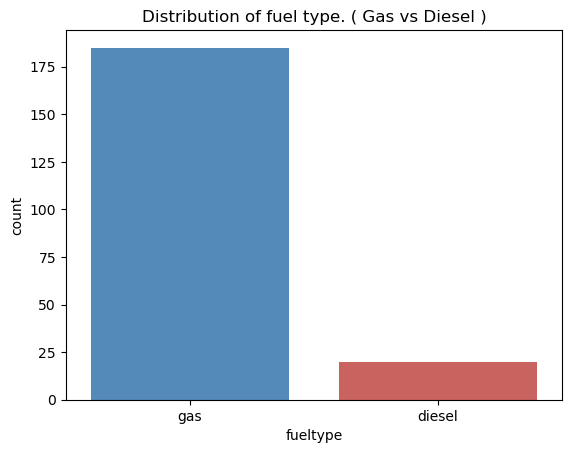

In [1666]:
sns.countplot(
    data=data,
    x= data['fueltype'],
    palette=['#428bca', '#d9534f']
)
plt.title('Distribution of fuel type. ( Gas vs Diesel )')
plt.show()

from the figure we can see that the count of gas car are much higher then the diesel one which indicates that the gas car in high demands.

In [1667]:
data.groupby('fueltype')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
fueltype,,,,
diesel,15838.1500,13852.5,7099.0,31600.0
gas,12999.7982,9989.0,5118.0,45400.0


we can see that the average price of gas car = 12999.7982 which is less then average price of diesel car = 15838.1500. Price of gas car is cheaper then diesel car in all comparison.

so we can say that fuel type affect the price of the car.

11. How does carbody (sedan, hatchback, convertible, etc.) relate to price?

In [1668]:
data['carbody'].value_counts()

carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [1669]:
data.groupby('carbody')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
carbody,,,,
convertible,21890.500000,17084.5,11595.0,37028.0
hardtop,22208.500000,19687.5,8249.0,45400.0
hatchback,10376.652386,8897.0,5118.0,31400.5
sedan,14344.270833,10846.5,5499.0,41315.0
wagon,12371.960000,11694.0,6918.0,28248.0


Yes, carbody strongly impacts price.
- Luxury / Premium Tier: Hardtop and Convertible carbody style have higher average prices ($\approx \$21,800 - \$22,200$) compared to other body types.
- Mid-Tier: Sedan ($\approx \$14,344$) and Wagon ($\approx \$12,372$) occupy the mid-range price segment.
- Economy Tier: Hatchback is the most affordable car body style with the lowest average price ($\approx \$10,377$) and lowest starting price ($\$5,118$).

12. Does drivewheel (fwd/rwd/4wd) show any price pattern?

In [1670]:
data.groupby('drivewheel')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
drivewheel,,,,
4wd,11087.463000,9233.0,7603.0,17859.167
fwd,9239.308333,8222.0,5118.0,23875.000
rwd,19910.809211,16912.5,6785.0,45400.000


yes, Drive wheel also impact the price of the car.
- premium: rwd (rear wheel drive) has the highest mean value ($\approx \$19910$), highest min value ($\approx \$5118.0$) and highest max value ($\approx \$45400.000$)
- medium: fwd (front wheel drive): its price lies between premium and economical car.
- economical: rwd ( four wheel drice) is the most affordable car based on the drive wheel.

13. Do cars with enginelocation = rear cost more than front-engine cars?

In [1671]:
data.groupby('enginelocation')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
enginelocation,,,,
front,12961.097361,10221.5,5118.0,45400.0
rear,34528.000000,34028.0,32528.0,37028.0


yes, The car with rear engine is more expencive then the car with front engine.

14. How does aspiration (std vs turbo) relate to price?

In [1672]:
data.groupby('aspiration')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
aspiration,,,,
std,12611.270833,9418.0,5118.0,45400.0
turbo,16298.166676,16503.0,7689.0,31600.0


Turbo aspiration cost more then the std aspiration.

15. Which cylindernumber is most common, and how does it affect price?

In [1673]:
data['cylindernumber'].value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

Four cylinder is the most common in the car.

In [1674]:
data.groupby('cylindernumber')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
cylindernumber,,,,
eight,37400.100000,35056.0,31400.5,45400.0
five,21630.469727,18920.0,13295.0,31600.0
four,10285.754717,8948.0,5118.0,22625.0
six,23671.833333,21037.5,13499.0,41315.0
three,5151.000000,5151.0,5151.0,5151.0
twelve,36000.000000,36000.0,36000.0,36000.0
two,13020.000000,12745.0,10945.0,15645.0


yes, Cylinder number in car affect the car price. As the number of cylinders increases, car prices increase substantially.

but in the case of 2 cylinder engine, it is special sports car engine so that it cost more then 3 cylinder engine.

16. Which enginetype is most common, and how does it affect price?

In [1675]:
data['enginetype'].value_counts()

enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

ohc engine type is the most common engine type.

In [1676]:
data.groupby('enginetype')['price'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
enginetype,,,,
dohc,18116.416667,16249.0,9298.0,35550.0
dohcv,31400.500000,31400.5,31400.5,31400.5
l,14627.583333,16105.0,5151.0,18150.0
ohc,11574.048426,9022.0,5195.0,41315.0
ohcf,13738.600000,9233.0,5118.0,37028.0
ohcv,25098.384615,19699.0,13499.0,45400.0
rotor,13020.000000,12745.0,10945.0,15645.0


yes engine type also affect the price of the car.
- most expensive engine type : dohcv with avg. price = 31400.50 and ohcv with avg. price = 25098.384615
- moderate expensive engine type: dohc with avg. price = 18116.416667 and l with avg. price = 14627.583333
- less expensive engine type: ohc with avg. price = 11574.048426 and hcf with avg. price = 13738.600000 and rotor with avg. price = 13020.000000

#### Numeric variables vs price
17. What is the correlation between price and numeric features like enginesize, horsepower, curbweight, citympg, highwaympg?

In [1677]:
data.corr(numeric_only=True)

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


18. Which numeric feature has the strongest positive correlation with price? Which has the strongest negative correlation?

Engine type feature has the strongest positive correlation with price i.e 0.874145. Citympg with -0.685751 and highwaympg with -0.697599 has the strongest negatice correlation with the price.

19. Is there a relationship between car dimensions (carlength, carwidth, carheight, wheelbase) and price?

In [1678]:
car_dimensions = ['carwidth', 'carlength', 'wheelbase', 'carheight', 'price']
data[car_dimensions].corr()

,carwidth,carlength,wheelbase,carheight,price
carwidth,1.000000,0.841118,0.795144,0.279210,0.759325
carlength,0.841118,1.000000,0.874587,0.491029,0.682920
wheelbase,0.795144,0.874587,1.000000,0.589435,0.577816
carheight,0.279210,0.491029,0.589435,1.000000,0.119336
price,0.759325,0.682920,0.577816,0.119336,1.000000


car width has the strongest postive correlation of 0.759325 with price. its means carwidth effect the price the most.

there is a clear relationship between car dimensions and price. However, horizontal dimensions (width, length, wheelbase) affect price significantly, while vertical dimension (height) has almost no impact.

20. Do cars with better mileage (citympg/highwaympg) tend to be cheaper?

In [1679]:
milage = ['citympg', 'highwaympg','price']
data[milage].corr()

,citympg,highwaympg,price
citympg,1.000000,0.971337,-0.685751
highwaympg,0.971337,1.000000,-0.697599
price,-0.685751,-0.697599,1.000000


Yes, cars with better mileage tend to be cheaper.The correlation matrix shows a strong negative correlation between mileage and price:
- City MPG vs. Price: r = -0.686
- Highway MPG vs. Price: r = -0.698 

Because the values are negative and close to -0.70, it confirms that as fuel efficiency (MPG) increases, the vehicle price significantly decreases.

#### Multivariate view
21. What does a correlation heatmap of all numeric features look like?

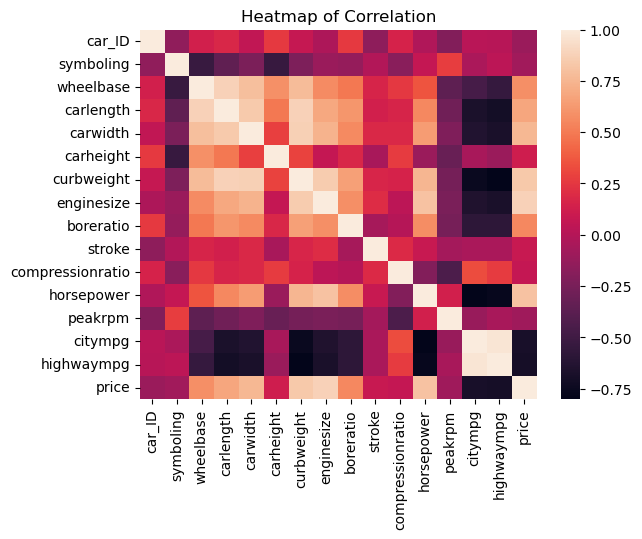

In [1680]:
sns.heatmap(data.corr(numeric_only=True))
plt.title('Heatmap of Correlation')
plt.show()

22. Are any features highly correlated with each other (multicollinearity), e.g. citympg vs highwaympg, or enginesize vs horsepower?

Yes, strong multicollinearity exists across several features in this dataset.
- citympg & highwaympg ($r = 0.97$): Almost perfectly collinear.
- carlength, carwidth, wheelbase, & curbweight ($r = 0.80 - 0.88$): Physical dimension features are heavily redundant with total vehicle weight.
- enginesize & horsepower ($r = 0.81$): Engine capacity strongly drives output power.

Impact on Regression: High multicollinearity can make standard linear regression coefficients unstable and inflated. For model building, techniques like Variance Inflation Factor (VIF) filtering, PCA (Principal Component Analysis), or Lasso/Ridge Regression should be considered to handle these redundant features.

# 2. Data Preprocessing
23. Does CarName need to be split into company and model? (extract just the brand)

In [1681]:
data['CarName'].sample(10)

26       dodge colt (sw)
62            mazda rx-4
202          volvo 244dl
53            mazda rx-4
35       honda accord lx
172      toyota cressida
8              audi 4000
143          subaru baja
120    plymouth fury iii
104         nissan teana
Name: CarName, dtype: object

yes Carame need to be split into the company and model.

In [1682]:
# Extract the first word (company name) from CarName
data['company'] = data['CarName'].apply(lambda x: x.split(' ')[0])
# Check unique brand names
print(data['company'].unique())

['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan' 'nissan'
 'peugeot' 'plymouth' 'porsche' 'porcshce' 'renault' 'saab' 'subaru'
 'toyota' 'toyouta' 'vokswagen' 'volkswagen' 'vw' 'volvo']


24. Are there inconsistent/misspelled company names (e.g. "maxda" vs "mazda", "porcshce" vs "porsche", "toyouta" vs "toyota", "vw"/"vokswagen" vs "volkswagen")? These need standardizing.

In [1683]:
# Fix brand name typos
data['company'] = data['company'].replace({
    'maxda': 'mazda',
    'porcshz': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
})
data['company'] = data['company'].replace(corrections)

In [1684]:
data['company'].value_counts()

company
toyota         32
mazda          17
nissan         17
honda          13
mitsubishi     13
subaru         12
volkswagen     12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
jaguar          3
chevrolet       3
renault         2
porcshce        1
mercury         1
Nissan          1
Name: count, dtype: int64

25. Should car_ID be dropped since it's just an identifier with no predictive value?

yes, car_ID should be dropped.

In [1685]:
# dropping the car_ID
data.drop('car_ID', axis=1, inplace=True)
# dropping the CarName
data.drop('CarName', axis=1, inplace=True)

26. Should symboling be treated as categorical or numeric?

In [1686]:
print(data['symboling'].dtype)
print("min symboling range:", data['symboling'].min())
print("max symboling range:", data['symboling'].max())



int64
min symboling range: -2
max symboling range: 3


Although represented by integers (-3 to +3), these numbers represent discrete insurance risk levels rather than continuous physical measurements. The intervals between numbers do not have a uniform numeric value or a strictly linear relationship with price. Converting it to categorical (or One-Hot Encoding it) prevents linear models from assuming a false continuous relationship

In [1687]:
# Convert symboling to an object/string type before One-Hot Encoding
data['symboling'] = data['symboling'].astype('str')
print(data['symboling'].dtype)

object


27. Do any numeric columns have wrong data types (e.g. stored as text)?

In [1688]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    object 
 1   fueltype          205 non-null    object 
 2   aspiration        205 non-null    object 
 3   doornumber        205 non-null    object 
 4   carbody           205 non-null    object 
 5   drivewheel        205 non-null    object 
 6   enginelocation    205 non-null    object 
 7   wheelbase         205 non-null    float64
 8   carlength         205 non-null    float64
 9   carwidth          205 non-null    float64
 10  carheight         205 non-null    float64
 11  curbweight        205 non-null    int64  
 12  enginetype        205 non-null    object 
 13  cylindernumber    205 non-null    object 
 14  enginesize        205 non-null    int64  
 15  fuelsystem        205 non-null    object 
 16  boreratio         205 non-null    float64
 1

yes, 'doornumber' and 'cylindernumber' columns have wrong data type. i.e string/object. we need to convert that into the numerical values.

In [1689]:
print(data['cylindernumber'].sample(5))
print(data['doornumber'].sample(5))

74     eight
137     four
118     four
44      four
98      four
Name: cylindernumber, dtype: object
113    four
171     two
75      two
78      two
37      two
Name: doornumber, dtype: object


In [1690]:
# Convert word-based numbers to actual integers
word_to_num = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 
    'five': 5, 'six': 6, 'sevel': 7, 'eight': 8, 
    'nine': 9, 'ten':10, 'eleven':11, 'twelve': 12
}

data['doornumber'] = data['doornumber'].map(word_to_num)
data['cylindernumber'] = data['cylindernumber'].map(word_to_num)

In [1691]:
print(data['doornumber'].sample(10))
print(data['doornumber'].sample(10))

97     4
93     4
77     2
33     2
35     4
201    4
25     4
100    4
127    2
153    4
Name: doornumber, dtype: int64
50     2
17     4
118    2
35     4
165    2
187    4
151    2
85     4
177    4
163    2
Name: doornumber, dtype: int64


28. Are there any negative or impossible values (e.g. negative price, zero horsepower) that indicate data entry errors?

In [1692]:
data.describe()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,3.121951,98.756585,174.049268,65.907805,53.724878,2555.565854,4.380488,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,0.994966,6.021776,12.337289,2.145204,2.443522,520.680204,1.080854,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,2.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,4.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,4.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,4.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,4.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,4.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,4.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


No, there are no any negative or impossible values that indicates data entry errors.

29. Do outliers in price, horsepower, or enginesize need to be capped/removed, or kept as valid?

Outliers in price, horsepower, and enginesize should be kept as valid data.

Reason: They represent real high-end luxury and performance sports cars (e.g., Porsche, BMW, Jaguar). Removing or capping them would distort the model's ability to predict high-end vehicle values accurately.

# 3. Feature Engineering
30. Should categorical variables be encoded (one-hot encoding for nominal like fueltype, carbody; label/ordinal encoding for ordered ones like cylindernumber)?

In [1693]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding using sklearn
nominal_cols = ['symboling', 'company', 'fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'fuelsystem']

# drop='first' avoids the dummy variable trap
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and transform nominal columns
encoded_array = ohe.fit_transform(data[nominal_cols])

# Convert back to DataFrame with clear feature names
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(nominal_cols), index=data.index)

# Combine with the main dataset and drop original text columns
data = pd.concat([data.drop(columns=nominal_cols), encoded_df], axis=1)

Yes. Categorical variables must be encoded into numeric formats using distinct techniques based on whether they have a natural order:
- Nominal Features (No Order): Apply One-Hot Encoding (with drop_first=True) to variables like company, fueltype, carbody, drivewheel, enginetype, fuelsystem, and aspiration to prevent imposing an artificial order.

In [1694]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 66 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   doornumber           205 non-null    int64  
 1   wheelbase            205 non-null    float64
 2   carlength            205 non-null    float64
 3   carwidth             205 non-null    float64
 4   carheight            205 non-null    float64
 5   curbweight           205 non-null    int64  
 6   cylindernumber       205 non-null    int64  
 7   enginesize           205 non-null    int64  
 8   boreratio            205 non-null    float64
 9   stroke               205 non-null    float64
 10  compressionratio     205 non-null    float64
 11  horsepower           205 non-null    int64  
 12  peakrpm              205 non-null    int64  
 13  citympg              205 non-null    int64  
 14  highwaympg           205 non-null    int64  
 15  price                205 non-null    flo

31. Should highly correlated features (e.g. citympg & highwaympg) be combined or one dropped to reduce multicollinearity?

In [1695]:
milage = ['citympg', 'highwaympg','price']
data[milage].corr()

,citympg,highwaympg,price
citympg,1.000000,0.971337,-0.685751
highwaympg,0.971337,1.000000,-0.697599
price,-0.685751,-0.697599,1.000000


in highly correlated featues, one of them should be dropped to reduce multicollinearlity.

Dropped citympg and keeping highwaympg, because highwaympg have a slightly stronger correlation with price (-0.698 vs -0.686) while removing the redundant correlation (r = 0.971) between the two features.

In [1696]:
data.drop('citympg', axis=1, inplace=True)

32. Would a derived feature like power-to-weight ratio (horsepower/curbweight) add predictive value?

Yes. A derived feature like power_to_weight ratio ($\frac{horsepower}{curbweight}$) adds substantial predictive value.

In [1697]:
# Create power-to-weight ratio (HP per pound/kg of car weight)
data['power_to_weight'] = data['horsepower'] / data['curbweight']

# Check its correlation with price
print("Correlation with price:", data['power_to_weight'].corr(data['price']))

Correlation with price: 0.5337668113809942


In [1698]:
data_copy = data

In [1699]:
data_copy

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,...,enginetype_ohcv,enginetype_rotor,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi,power_to_weight
0,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.043564
1,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.043564
2,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.054552
3,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.043646
4,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.040722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,4,109.1,188.8,68.9,55.5,2952,4,141,3.78,3.15,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.038618
201,4,109.1,188.8,68.8,55.5,3049,4,141,3.78,3.15,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.052476
202,4,109.1,188.8,68.9,55.5,3012,6,173,3.58,2.87,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.044489
203,4,109.1,188.8,68.9,55.5,3217,6,145,3.01,3.40,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.032950


### Standardization.
We use StandardScaler to bring all continuous measurements (curbweight, horsepower, highwaympg, ratios) onto the same standard scale ($\mu=0, \sigma=1$). This prevents large range numerical values from dominating the models and decrease our accuracy of the model

In [1700]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
x = data.drop(columns=['price'])
y = data['price']

# 2. Split FIRST into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Define the list of continuous numerical columns to scale
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4. Initialize Scaler
scaler = StandardScaler()

# 5. Fit and transform ONLY x_train, then transform x_test using num_cols
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols]  = scaler.transform(x_test[num_cols])

In [1701]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((164, 65), (164,), (41, 65), (41,))

## Regression 

### 1. Linear Regression

In [1702]:
from sklearn.linear_model import LinearRegression

In [1703]:
linear_regression = LinearRegression()
linear_regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [1704]:
linear_regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [1705]:
# slope of 65 features.
linear_regression.coef_

array([ 2.17362336e+02,  1.56634339e+03, -1.82887400e+03,  8.26480283e+02,
       -5.59932284e+02, -1.35789688e+03, -1.19545325e+03,  4.13452534e+03,
       -1.00459150e+03,  2.34640980e+01,  2.15249006e+02,  8.37474282e+03,
        8.48662626e+02,  1.29883890e+02, -4.47385579e+00,  2.16602061e+02,
        9.21741601e+01, -2.49347139e+02, -2.15374188e+02,  3.79102726e+02,
        7.55446446e+02,  1.61200576e+03,  1.59171951e+03, -1.15503330e+02,
       -3.82986375e+02,  3.86600454e+02,  2.03521040e+01,  3.20294869e+01,
        3.25864903e+02,  3.65339542e+01, -3.43674135e+02,  6.93026500e+01,
       -1.98578609e+02, -3.89395740e+02,  5.03072348e+02,  1.24810619e+03,
       -9.63508241e+01,  9.22125078e+02, -2.50718875e+02, -2.21320862e+02,
        2.36204491e+02,  4.91683015e+02, -1.06008172e+02,  9.47781107e+02,
       -3.61453279e+02, -1.45191631e+03, -1.38294568e+03, -1.03310904e+03,
       -1.16188000e+02,  2.03433346e+02,  1.29771697e+03, -1.46408212e+02,
       -1.98578609e+02, -

In [1706]:
# intercepts
linear_regression.intercept_

np.float64(13223.414634146344)

In [1707]:
y_pred_test = linear_regression.predict(x_test)
y_pred_test

array([30320.00438611, 22347.47003108,  9188.40721407, 13016.39226621,
       32131.21206875,  6934.60341192,  8381.07103649,  7521.14224091,
        9563.71540262,  8474.72222842, 14274.87884099,  6825.48351029,
       15193.12626573,  9354.2105766 , 43913.84901634,  7313.10121832,
        1931.86289593, 14499.46472853,  8988.73422101,  9535.56288332,
       11086.88005664, 16278.60766716,  7496.22935404,  4747.22762803,
        7558.38596821, 31202.89337983, 10912.96797797, 16177.09646622,
        6533.4042568 , 16204.59741383, 32307.20148196,  6782.89898763,
        6454.54657351, 19076.93688443,  8136.33473108, 32945.80174633,
       11470.45464532, 12723.12256472,  8530.9654474 , 15258.00036334,
        8100.85323768])

In [1708]:
y_test

15     30760.000
9      17859.167
100     9549.000
132    11850.000
68     28248.000
95      7799.000
159     7788.000
162     9258.000
147    10198.000
182     7775.000
191    13295.000
164     8238.000
65     18280.000
175     9988.000
73     40960.000
152     6488.000
18      5151.000
82     12629.000
86      8189.000
143     9960.000
60      8495.000
101    13499.000
98      8249.000
30      6479.000
25      6692.000
16     41315.000
168     9639.000
195    13415.000
97      7999.000
194    12940.000
67     25552.000
120     6229.000
154     7898.000
202    21485.000
79      7689.000
69     28176.000
145    11259.000
55     10945.000
45      8916.500
84     14489.000
146     7463.000
Name: price, dtype: float64

In [1709]:
y_pred_test.shape, y_test.shape

((41,), (41,))

In [1710]:
x_train.shape, y_train.shape

((164, 65), (164,))

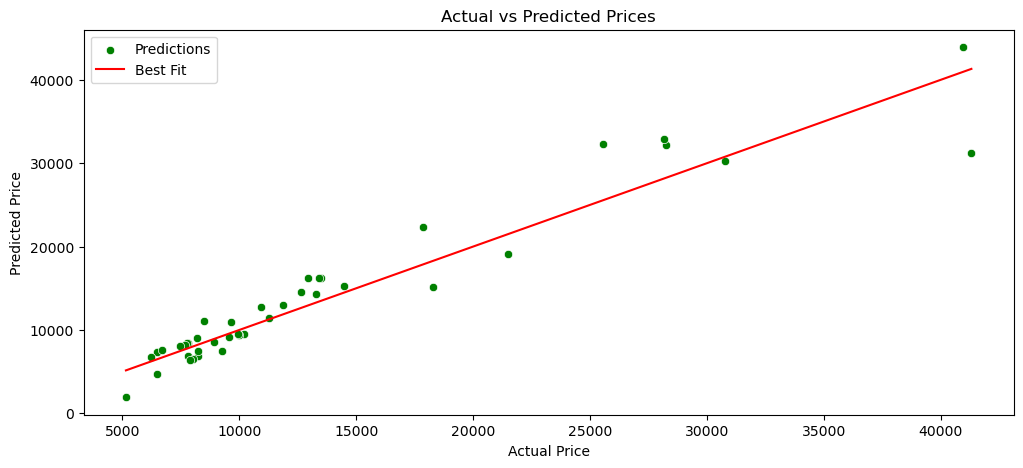

In [1711]:
## Visualize this model

plt.figure(figsize=(12, 5))
# 1. Plot actual vs predicted scatter points
sns.scatterplot(x=y_test, y=y_pred_test, color='g', label='Predictions')

# 2. Draw the diagonal line of Best fit.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r', label='Best Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

In [1712]:
## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

# R square and Adjusted R square
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)
print(f"R2 score: {score}")


MSE: 7392389.787943535
MAE: 1922.758772016182
RMSE: 2718.894957136729
R2 score: 0.9063590921063864


In [1713]:
import pickle
pickle.dump(linear_regression, open('regressor.pkl', 'wb'))

In [1714]:
# Ridge Regression
from sklearn.linear_model import Ridge
ridge_reg=Ridge(alpha=0.1)
ridge_reg.fit(x_train,y_train)
y_pred_ridge = ridge_reg.predict(x_test)

## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

# R2 score
from sklearn.metrics import r2_score
print(f"R2 score: {r2_score(y_test, y_pred_ridge)}")

MSE: 7653957.828865168
MAE: 1939.3599740011723
RMSE: 2766.578722694362
R2 score: 0.9030457564286868


In [1715]:
# Lasso Regression
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(x_train, y_train)
y_pred_lasso = lasso_reg.predict(x_test)

## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

# R2 score
from sklearn.metrics import r2_score
print(f"R2 score: {r2_score(y_test, y_pred_lasso)}")

MSE: 7421229.099375359
MAE: 1927.429453874768
RMSE: 2724.1932933210446
R2 score: 0.9059937786714932


In [1716]:
# ElasticNet Regression
from sklearn.linear_model import ElasticNet

elastic_reg = ElasticNet(alpha=0.005,l1_ratio=0.9)
elastic_reg.fit(x_train,y_train)
y_pred_elastic = elastic_reg.predict(x_test)

## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))

# R2 score
from sklearn.metrics import r2_score
print(f"R2 score: {r2_score(y_test, y_pred_elastic)}")

MSE: 7568681.269740359
MAE: 1931.6862659560297
RMSE: 2751.1236376688635
R2 score: 0.9041259719811072


2. Polyminal Regression

In [1717]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Choose degree (degree=2 creates quadratic terms x^2 and interaction terms x1*x2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transform numerical features on train and test sets
# (Use x_train and x_test from your existing split)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# 3. Fit Linear Regression on polynomial features
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

# 4. Make Predictions
y_pred_poly = poly_model.predict(x_test_poly)

In [1718]:
y_pred_poly.shape, y_test.shape

((41,), (41,))

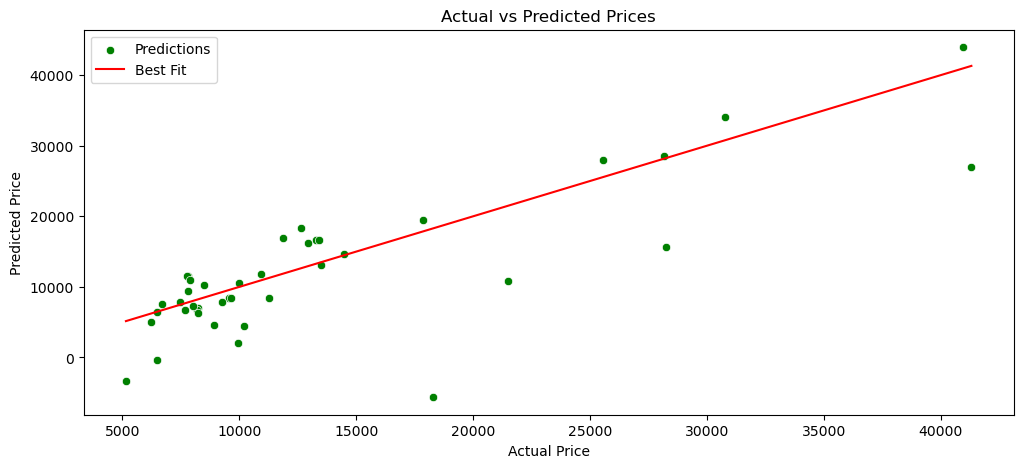

In [1719]:
## Visualize this model

plt.figure(figsize=(12, 5))
# 1. Plot actual vs predicted scatter points
sns.scatterplot(x=y_test, y=y_pred_poly, color='g', label='Predictions')

# 2. Draw the diagonal line of Best fit.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r', label='Best Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

In [1720]:
## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

# R square
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_poly)
print(f"R2 score: {score}")

MSE: 35932468.28555776
MAE: 3847.7261779455407
RMSE: 5994.369715454475
R2 score: 0.544836101769718


In [1721]:
from sklearn.tree import DecisionTreeRegressor
decision_reg = DecisionTreeRegressor(random_state=42)
decision_reg.fit(x_train, y_train)
y_pred_decision = decision_reg.predict(x_test)

## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_decision))
print("MAE:", mean_absolute_error(y_test, y_pred_decision))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_decision)))

# R2 score
from sklearn.metrics import r2_score
print(f"R2 score: {r2_score(y_test, y_pred_decision)}")

MSE: 6529338.746387537
MAE: 1750.6626097560975
RMSE: 2555.257080293006
R2 score: 0.9172915355256497


In [1722]:
# Hyperparameter Tuning
import warnings
warnings.filterwarnings('ignore')

# param = {
#     'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
#     'splitter': ['best', 'random'],
#     'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25, None],
#     'max_features': ['auto', 'sqrt', 'log2', None]
# }


param = {
    # Splitting criterion
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    
    # Strategy used to split at each node
    'splitter': ['best', 'random'],
    
    # Maximum depth of the tree (controls model complexity)
    'max_depth': [3, 5, 10, 15, 20, None],
    
    # Minimum number of samples required to split an internal node
    'min_samples_split': [2, 5, 10, 20],
    
    # Minimum number of samples required at a leaf node
    'min_samples_leaf': [1, 2, 4, 8],
    
    # Number of features to consider when looking for the best split
    'max_features': [None, 'sqrt', 'log2','auto'],
    
    # Complexity parameter used for Minimal Cost-Complexity Pruning
    'ccp_alpha': [0.0, 0.01, 0.1]
}


from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(decision_reg, param_grid=param)
grid.fit(x_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'ccp_alpha': [0.0, 0.01, ...], 'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'poisson'


In [1723]:
grid.best_params_

{'ccp_alpha': 0.1,
 'criterion': 'poisson',
 'max_depth': 10,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'splitter': 'best'}

In [1729]:
# decision_reg2 = DecisionTreeRegressor(ccp_alpha=0.1, criterion='poisson', max_depth= 10, max_features='log2', min_samples_leaf=1, min_samples_split=10, splitter='best')
decision_reg2 = DecisionTreeRegressor(**grid.best_params_, random_state=42)
decision_reg2.fit(x_train,y_train)
y_pred_decision2 = decision_reg2.predict(x_test)

## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("MSE:", mean_squared_error(y_test, y_pred_decision2))
print("MAE:", mean_absolute_error(y_test, y_pred_decision2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_decision2)))

# R2 score
from sklearn.metrics import r2_score
print(f"R2 score: {r2_score(y_test, y_pred_decision2)}")

MSE: 17539226.22658768
MAE: 2662.0378790166474
RMSE: 4187.985939158306
R2 score: 0.7778270471765748


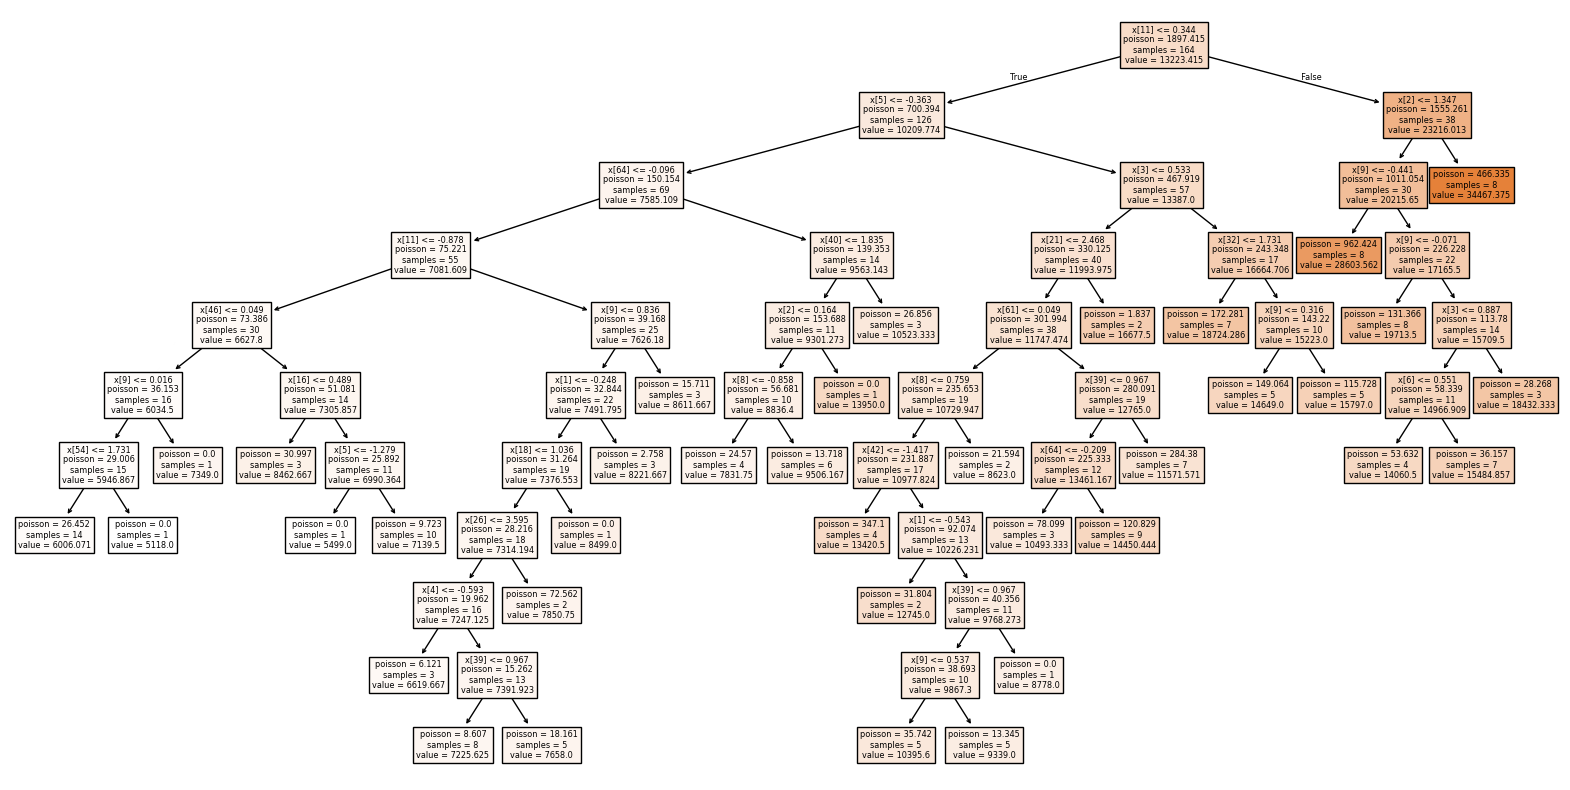

In [1730]:
 # Visualizing the Decision Tree
from sklearn import tree
plt.figure(figsize=(20, 10))
tree.plot_tree(decision_reg2, filled = True)
plt.show()

In [1731]:
# Store each model's predictions here
models = {
    'Linear Regression': y_pred_test,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'ElasticNet': y_pred_elastic,
    'Polynomial Regression': y_pred_poly,
    'Decision Tree (default)': y_pred_decision,
    'Decision Tree (tuned)': y_pred_decision2,
}

results = []
for name, y_pred in models.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'R2 Score': r2, 'MSE':mse ,'RMSE': rmse, 'MAE': mae})

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,R2 Score,MSE,RMSE,MAE
0,Decision Tree (default),0.917292,6.529339e+06,2555.257080,1750.662610
1,Linear Regression,0.906359,7.392390e+06,2718.894957,1922.758772
2,Lasso Regression,0.905994,7.421229e+06,2724.193293,1927.429454
3,ElasticNet,0.904126,7.568681e+06,2751.123638,1931.686266
4,Ridge Regression,0.903046,7.653958e+06,2766.578723,1939.359974
5,Decision Tree (tuned),0.777827,1.753923e+07,4187.985939,2662.037879
6,Polynomial Regression,0.544836,3.593247e+07,5994.369715,3847.726178


so among all the Regression models used for the car price perdiction. Decision Tree (default) performs the best.

In [1732]:
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': decision_reg.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
7,enginesize,0.650337
5,curbweight,0.263552
13,highwaympg,0.017764
3,carwidth,0.015596
9,stroke,0.015007
11,horsepower,0.012162
12,peakrpm,0.007554
4,carheight,0.005392
64,power_to_weight,0.004967
8,boreratio,0.002057


so among the multiple independant features, 'enginesize' and 'curbweight' features contains altogether about 91% importance and other rest features have very little importance. so the main goal of the business is to focus on the 'enginesize' and 'curbweight' for the car market